# 04 — Game Predictor

Run all cells, then use `predict_game('HOME', 'AWAY')` at the bottom to predict any matchup.

**Team abbreviations:**
```
ATL  BOS  BKN  CHA  CHI  CLE  DAL  DEN  DET  GSW
HOU  IND  LAC  LAL  MEM  MIA  MIL  MIN  NOP  NYK
OKC  ORL  PHI  PHX  POR  SAC  SAS  TOR  UTA  WAS
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, RocCurveDisplay
from xgboost import XGBClassifier

matchups = pd.read_csv('../data/cleaned/matchups_features.csv', parse_dates=['GAME_DATE'])
raw      = pd.read_csv('../data/cleaned/team_logs_all_seasons.csv', parse_dates=['GAME_DATE'])
DIFF_FEATURES = [c for c in matchups.columns if c.startswith('DIFF_')]
print(f'Ready: {len(matchups)} matchups | {len(DIFF_FEATURES)} features')

Ready: 3638 matchups | 24 features


In [3]:
# Train models
df_s = matchups.sort_values('GAME_DATE').reset_index(drop=True)
split_idx = int(len(df_s) * 0.80)
train, test = df_s.iloc[:split_idx], df_s.iloc[split_idx:]
X_train, y_train = train[DIFF_FEATURES], train['home_win']
X_test,  y_test  = test[DIFF_FEATURES],  test['home_win']

scaler = StandardScaler()
Xtr_s, Xte_s = scaler.fit_transform(X_train), scaler.transform(X_test)

model_defs = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                          subsample=0.8, colsample_bytree=0.8,
                                          eval_metric='logloss', random_state=42),
}
results = {}
for name, model in model_defs.items():
    Xtr = Xtr_s if name=='Logistic Regression' else X_train
    Xte = Xte_s if name=='Logistic Regression' else X_test
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:,1]
    results[name] = dict(model=model, preds=preds, proba=proba,
                          accuracy=accuracy_score(y_test,preds), roc_auc=roc_auc_score(y_test,proba))

pd.DataFrame({'Accuracy':{n:f"{r['accuracy']:.1%}" for n,r in results.items()},
              'ROC-AUC': {n:f"{r['roc_auc']:.3f}"  for n,r in results.items()}})

,Accuracy,ROC-AUC
Logistic Regression,65.4%,0.709
Random Forest,65.8%,0.702
XGBoost,62.6%,0.668


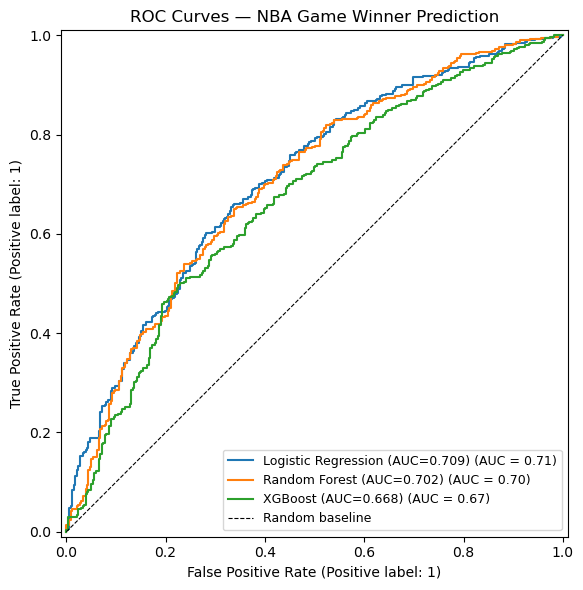

In [5]:
# ROC Curves
fig, ax = plt.subplots(figsize=(7,6))
for name, res in results.items():
    RocCurveDisplay.from_predictions(y_test, res['proba'], name=f"{name} (AUC={res['roc_auc']:.3f})", ax=ax)
ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random baseline')
ax.set_title('ROC Curves — NBA Game Winner Prediction')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

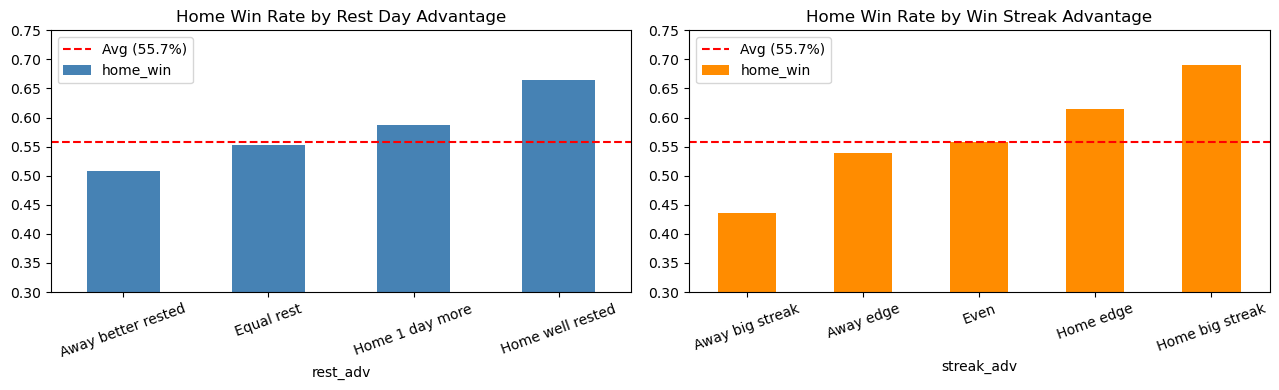

In [7]:
# Home advantage analysis
avg = matchups['home_win'].mean()
matchups['rest_adv']   = pd.cut(matchups['DIFF_REST_DAYS'], bins=[-8,-1,0,1,8],
                                 labels=['Away better rested','Equal rest','Home 1 day more','Home well rested'])
matchups['streak_adv'] = pd.cut(matchups['DIFF_WIN_STREAK'], bins=[-30,-3,-1,1,3,30],
                                 labels=['Away big streak','Away edge','Even','Home edge','Home big streak'])

fig, axes = plt.subplots(1,2,figsize=(13,4))
matchups.groupby('rest_adv', observed=True)['home_win'].mean().plot(kind='bar', ax=axes[0], color='steelblue', rot=20)
axes[0].axhline(avg, color='red', linestyle='--', label=f'Avg ({avg:.1%})')
axes[0].set_title('Home Win Rate by Rest Day Advantage'); axes[0].set_ylim(0.3,0.75); axes[0].legend()

matchups.groupby('streak_adv', observed=True)['home_win'].mean().plot(kind='bar', ax=axes[1], color='darkorange', rot=20)
axes[1].axhline(avg, color='red', linestyle='--', label=f'Avg ({avg:.1%})')
axes[1].set_title('Home Win Rate by Win Streak Advantage'); axes[1].set_ylim(0.3,0.75); axes[1].legend()
plt.tight_layout()
plt.show()

In [9]:
# Game predictor function
ROLL_COLS = ['PTS','REB','AST','STL','BLK','TOV','FG_PCT','FG3_PCT','FT_PCT','PLUS_MINUS']
season_2425 = raw[raw['GAME_DATE'] >= '2024-10-01'].copy()

def predict_game(home_abbr, away_abbr, n_games=10):
    def get_team(abbr):
        t = season_2425[season_2425['TEAM_ABBREVIATION']==abbr].sort_values('GAME_DATE')
        if len(t)==0: raise ValueError(f"Team '{abbr}' not found.")
        stats = t.tail(n_games)[ROLL_COLS].mean()
        streak = 0
        for win in t['WIN'].tolist():
            streak = max(streak,0)+1 if win==1 else min(streak,0)-1
        return stats, streak

    hs, hstr = get_team(home_abbr)
    as_, astr = get_team(away_abbr)
    diff = hs - as_

    row = {}
    for c in ROLL_COLS:
        row[f'DIFF_{c}_ROLL5']  = diff[c]
        row[f'DIFF_{c}_ROLL10'] = diff[c]
    row['DIFF_OPP_PTS_ROLL5']  = 0.0
    row['DIFF_OPP_PTS_ROLL10'] = 0.0
    row['DIFF_REST_DAYS']  = 0
    row['DIFF_WIN_STREAK'] = hstr - astr

    X = pd.DataFrame([row])[DIFF_FEATURES]

    print(f"\n{'='*52}")
    print(f"   {home_abbr} (HOME)  vs  {away_abbr} (AWAY)")
    print(f"   {home_abbr}: avg {hs['PTS']:.1f} pts | streak {hstr:+d}")
    print(f"   {away_abbr}: avg {as_['PTS']:.1f} pts | streak {astr:+d}")
    print(f"{'─'*52}")
    probs = {}
    for name, res in results.items():
        Xin  = scaler.transform(X) if name=='Logistic Regression' else X
        prob = res['model'].predict_proba(Xin)[0][1]
        probs[name] = prob
        pick = home_abbr if prob>0.5 else away_abbr
        print(f"   {name:22s}  {home_abbr}: {prob:.1%}  {away_abbr}: {1-prob:.1%}  → {pick}")
    avg_p = np.mean(list(probs.values()))
    winner = home_abbr if avg_p>0.5 else away_abbr
    print(f"{'─'*52}")
    print(f"   CONSENSUS: {winner} wins  ({max(avg_p,1-avg_p):.1%} confidence)")
    print(f"{'='*52}\n")

print('predict_game() is ready! See examples below.')

predict_game() is ready! See examples below.


In [11]:
# Example predictions
predict_game('OKC', 'CLE')   # #1 vs #2 from 2024-25
predict_game('BOS', 'NYK')   # Classic rivalry
predict_game('LAL', 'GSW')   # West showdown


   OKC (HOME)  vs  CLE (AWAY)
   OKC: avg 125.2 pts | streak +4
   CLE: avg 119.7 pts | streak -1
────────────────────────────────────────────────────
   Logistic Regression     OKC: 72.4%  CLE: 27.6%  → OKC
   Random Forest           OKC: 74.7%  CLE: 25.3%  → OKC
   XGBoost                 OKC: 79.4%  CLE: 20.6%  → OKC
────────────────────────────────────────────────────
   CONSENSUS: OKC wins  (75.5% confidence)


   BOS (HOME)  vs  NYK (AWAY)
   BOS: avg 113.8 pts | streak +2
   NYK: avg 110.7 pts | streak +1
────────────────────────────────────────────────────
   Logistic Regression     BOS: 63.3%  NYK: 36.7%  → BOS
   Random Forest           BOS: 60.8%  NYK: 39.2%  → BOS
   XGBoost                 BOS: 75.7%  NYK: 24.3%  → BOS
────────────────────────────────────────────────────
   CONSENSUS: BOS wins  (66.6% confidence)


   LAL (HOME)  vs  GSW (AWAY)
   LAL: avg 117.4 pts | streak -1
   GSW: avg 119.6 pts | streak -1
────────────────────────────────────────────────────
   Logis

## Try your own matchup!
Change the teams below and re-run the cell.

In [13]:
predict_game('MIN', 'MIA')  # Change these to any two teams!


   MIN (HOME)  vs  MIA (AWAY)
   MIN: avg 118.6 pts | streak +3
   MIA: avg 120.6 pts | streak -1
────────────────────────────────────────────────────
   Logistic Regression     MIN: 52.7%  MIA: 47.3%  → MIN
   Random Forest           MIN: 53.1%  MIA: 46.9%  → MIN
   XGBoost                 MIN: 52.6%  MIA: 47.4%  → MIN
────────────────────────────────────────────────────
   CONSENSUS: MIN wins  (52.8% confidence)

